## Generate data

In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

### Spring-Mass-Damper (SMD) system 

\begin{equation}
    m \ddot{x} + c \dot{x} + k x = u
\end{equation}

> State space representaion

\begin{equation}
    \bold{x} = \begin{bmatrix} x \\ \dot{x} \end{bmatrix} = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}
\end{equation}

\begin{align}
    \\
    \dot{\bold{x}} = \begin{bmatrix} \dot{x_1} \\ \dot{x_2} \end{bmatrix} &= \begin{bmatrix} 0 & 1 \\   -\frac{k}{m} & -\frac{c}{m} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} 0 \\ \frac{1}{m} \end{bmatrix} u
    \\\\
    \dot{\bold{x}} &= A \dot{\bold{x}} + B u

    
\end{align}


> Sensor measurement

\begin{equation}
    \bold{y} = C \bold{x} = I \bold{x}
\end{equation}


In [2]:
# SYSTEM PARAMETERS
m, c, k = 1.0, 0.5, 5.0

# SYSTEM MATRICES
Ac_true = np.array([[0,1],[-k/m, -c/m]])
Bc_true = np.array([[0],[1/m]])

In [3]:
# SYSTEM PROPERTIES
eigen_vals  = np.linalg.eig(Ac_true)[0]
Obser_mat   = np.vstack([Ac_true, np.linalg.matrix_power(Ac_true,2)]) # C matrix is identiy


print(f"Eigen Values: {np.round(eigen_vals[0],2)} | {np.round(eigen_vals[1],2)}")
print(f"Rank of observability matrix: {np.linalg.matrix_rank(Obser_mat)}")

Eigen Values: (-0.25+2.22j) | (-0.25-2.22j)
Rank of observability matrix: 2


### System dynamics and Control law

In [21]:
# Simulation settings
N_train         = 10000
T_train         = 60
t_eval_train    = np.linspace(0, T_train, N_train)
dt_train        = t_eval_train[1] - t_eval_train[0]

In [5]:
def dynamics(t, x_t, u_func, A_mat,B_mat):
    x_t = x_t.reshape(2,1)
    u = u_func(t)
    dx_t = A_mat @ x_t + B_mat @ u.reshape(1,1)
    return dx_t.reshape(2,)


# # Multi-sine - input ((persistently exciting))
U_traj = (
    np.sin(1*t_eval_train) +
    0.5*np.sin(3*t_eval_train) +
    0.3*np.sin(7*t_eval_train) + 0.2*np.random.randn(len(t_eval_train))
)

# # Pseudo Random Binary Sequence (PRBS) system identification is a technique
# U_traj = np.sign(np.random.randn(len(t_eval)))

# White-noise - input
# U_traj = 1*np.random.uniform(low=0, high=2, size=len(t_eval_train))



def control_train(t):
    idx = min(int(t / dt_train), len(U_traj)-1)
    return U_traj[idx]

Text(0, 0.5, 'u (N)')

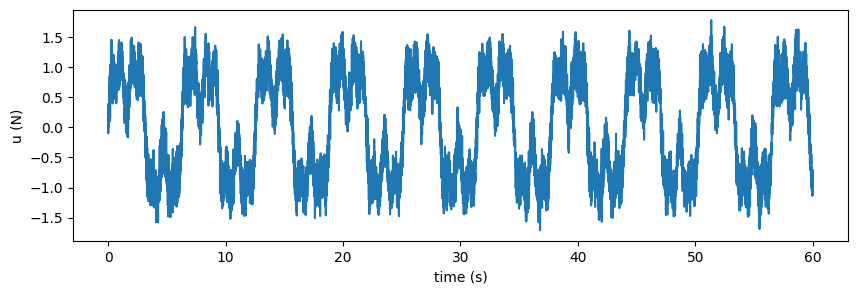

In [6]:
plt.figure(figsize=(10,3))
plt.plot(t_eval_train,U_traj)
plt.xlabel("time (s)")
plt.ylabel("u (N)")

In [22]:
# Initial condition
x0 = np.round(np.random.uniform(low=0,high=1, size=2), 2) # [1.0, 0.0]

print(f"Initial conidtion: {x0}")
print(f"t_start: {t_eval_train[0]} | t_end: {t_eval_train[-1]} | t_points: {t_eval_train.shape[0]} | Sampling frequency {1/dt_train} Hz")

Initial conidtion: [0.3 0.6]
t_start: 0.0 | t_end: 60.0 | t_points: 10000 | Sampling frequency 166.65 Hz


Text(0, 0.5, 'velocity (m/s)')

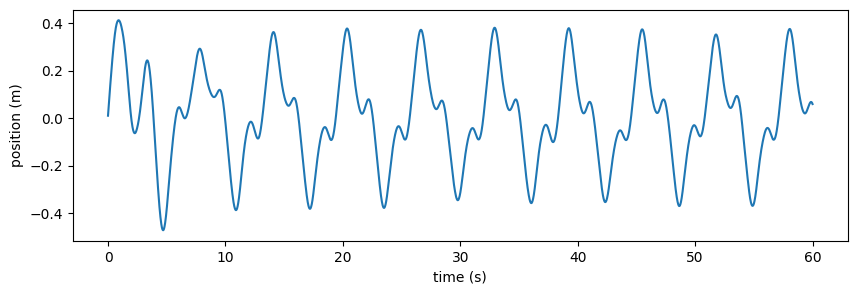

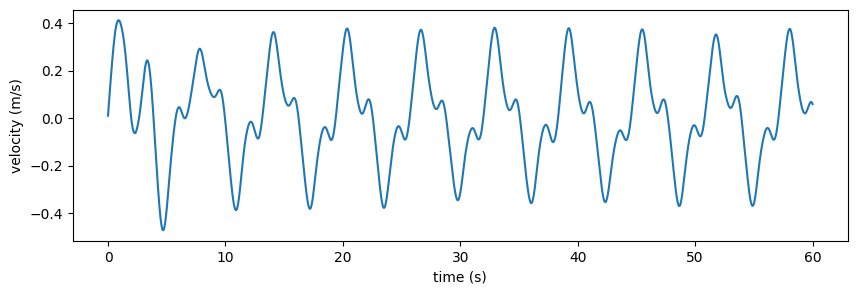

In [8]:
# Simulation of dynamics
sol = solve_ivp(dynamics, [0, T_train], x0, t_eval=t_eval_train, args=(control_train,Ac_true,Bc_true))

plt.figure(figsize=(10,3))
plt.plot(t_eval_train,sol.y[0])
plt.xlabel("time (s)")
plt.ylabel("position (m)")

plt.figure(figsize=(10,3))
plt.plot(t_eval_train,sol.y[0])
plt.xlabel("time (s)")
plt.ylabel("velocity (m/s)")

In [9]:
# Collect data
data = []
for i in range(len(t_eval_train)-1):
    t = t_eval_train[i]
    x = sol.y[:, i]
    u = U_traj[i] # control(t)
    x_next = sol.y[:, i+1]
    data.append([t, x[0], x[1], u, x_next[0], x_next[1]])


df = pd.DataFrame(data, columns=["t", "x1", "x2", "u", "x1_next", "x2_next"])
df.to_csv("smd_data.csv", index=False)

### Load saved data

In [10]:
# Load data
df = pd.read_csv("smd_data.csv")

X       = df[["x1", "x2"]].values.T
X_next  = df[["x1_next", "x2_next"]].values.T
U       = df[["u"]].values.T

print(X.shape, X_next.shape, U.shape)

(2, 9999) (2, 9999) (1, 9999)


In [11]:
# Observable functions
def lift(X):
    #(identity — linear system)
    return X

### Estimating Koopman Matrix

##### Continuous and infinite dimensional:

> Lifting via Observable functions

- SMD system is linear
- Linear observable

\begin{equation}
    g(\bold{x}) = \bold{x}
\end{equation}

> Linear representation of Koopman function

\begin{equation}
    g_{(f(\bold{x}_{(t)},u_{(t)}))} = g_{(A \bold{x}_{(t)} + B u_{(t)})} = \mathcal{K} g_{(\bold{x}_{(t)})}
\end{equation}

##### Discrete and finite-dimensional Koopman approximation with control:

> Assume there exists a finite basis such that: Galerkin / least-squares projection

\begin{equation}
    g_{(\bold{x}_{[k+1]})} \approx A_d g_{(\bold{x}_{[k]})} + B_d u_{[k]}
\end{equation}

> Stack m - measurements

\begin{align}
    Z &= \begin{bmatrix} g_{(\bold{x}_{[0]})} & g_{(\bold{x}_{[1]})} & . . . & g_{(\bold{x}_{[m]})}\end{bmatrix} \in \mathcal{R}^{n \times m}\\\\
    Z_{next} &= \begin{bmatrix} g_{(\bold{x}_{[1]})} & g_{(\bold{x}_{[2]})} & . . . & g_{(\bold{x}_{[m+1]})}\end{bmatrix} \in \mathcal{R}^{n \times m}\\\\
    U &= \begin{bmatrix} u_{[0]} & u_{[1]} & ... & u_{[m]} \end{bmatrix} \in \mathcal{R}^{n_u \times m}
\end{align}

we can simplify as:

\begin{equation}
    Z_{next} = A_d Z + B_d U = \begin{bmatrix} A_d & B_d \end{bmatrix} \begin{bmatrix} Z \\ U \end{bmatrix} = K \Omega
\end{equation}

where

\begin{align}
    K &:= \begin{bmatrix} A_d & B_d \end{bmatrix} \in \mathcal{R}^{n \times (n+1)}\\\\
    \Omega &:= \begin{bmatrix} Z \\ U \end{bmatrix} \in \mathcal{R}^{(n + n_u) \times m}
\end{align}

> Solve for $K$

\begin{equation}
    \hat{K} = \underset{K}{\operatorname{argmin}} \lVert Z_{next} - K \Omega \rVert_F
\end{equation}

In [12]:
Z       = lift(X)
Z_next  = lift(X_next)

# Stack data
ZU = np.vstack((Z, U))

# Least squares
K = Z_next @ np.linalg.pinv(ZU)

# Extract Ad, Bd
n = Z.shape[0]
Ad = K[:, :n]
Bd = K[:, n:]

In [13]:
# Rank of \Omega:
print(f"Rank of the omega vector: {np.linalg.matrix_rank(ZU)} | Required rank: {ZU.shape[0]}")



Rank of the omega vector: 3 | Required rank: 3


In [14]:
assert np.linalg.matrix_rank(ZU) == ZU.shape[0]

#### Estimating continous system matrix from estimated discrete matrices

\begin{equation}
    A_d = \mathrm{e}^{A_{est} dt}
\end{equation}


\begin{equation}
    B_d = \int_{0}^{dt} \mathrm{e}^{A_{est} \tau} B_{est} d\tau   
\end{equation}


\begin{equation}
    A_{est} = \frac{1}{dt}\ln{(A_d)}
\end{equation}


\begin{equation}
    B_{est} = A_{est}^{−1} ​( A​ − I) B_d
\end{equation}

In [15]:
# Estimated is discrete version of the A_mat:
from scipy.linalg import logm
# A_est = logm(Ad) / dt #(A-np.eye(2))/(t_eval[1]-t_eval[0])

n = Ad.shape[0]
m = Bd.shape[1]

M = np.block([
    [Ad, Bd],
    [np.zeros((m, n)), np.eye(m)]
])

M_log = logm(M) / dt_train

Ac_est = M_log[:n, :n]
Bc_est = M_log[:n, n:]

In [16]:
print(f"> Actual A matrix: {eigen_vals}\n")
print(Ac_true)

print(f"\n> Estimated  A matrix: {np.linalg.eig(Ac_est)[0]} \n")
print(Ac_est)

print(f"\n> Error of A_est:\n")
print(Ac_true - Ac_est)

> Actual A matrix: [-0.25+2.2220486j -0.25-2.2220486j]

[[ 0.   1. ]
 [-5.  -0.5]]

> Estimated  A matrix: [-0.2388014+2.1952715j -0.2388014-2.1952715j] 

[[ 3.04592426e-05  1.00000733e+00]
 [-4.87622189e+00 -4.77633257e-01]]

> Error of A_est:

[[-3.04592426e-05 -7.32822421e-06]
 [-1.23778111e-01 -2.23667435e-02]]


In [17]:
print(f"> Actual B matrix:\n")
print(Bc_true)

print(f"\n> Estimated B matrix:\n")
print(Bc_est)

print(f"\n> Error of B_est:\n")
print(Bc_true - Bc_est)

> Actual B matrix:

[[0.]
 [1.]]

> Estimated B matrix:

[[-8.67068154e-06]
 [ 9.50945746e-01]]

> Error of B_est:

[[8.67068154e-06]
 [4.90542542e-02]]


### Validate Koopman Model

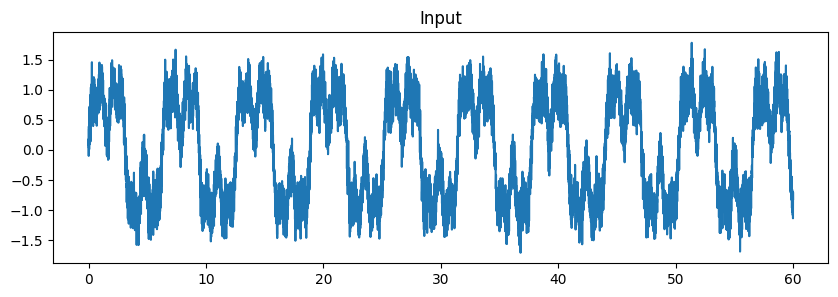

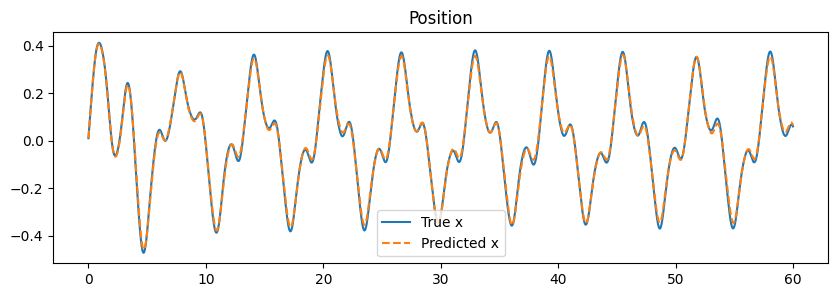

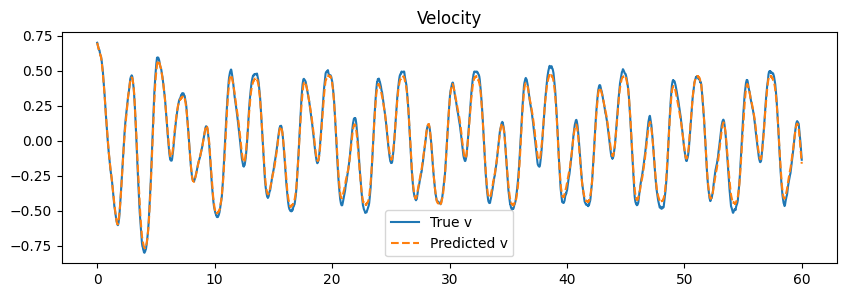

In [18]:
# Rollout prediction

x_pred = np.zeros_like(X)
x_pred[:, 0] = X[:, 0]

for k in range(X.shape[1]-1):
    z = lift(x_pred[:, k].reshape(-1,1))
    u = U[:, k].reshape(-1,1)
    z_next = Ad @ z + Bd @ u
    x_pred[:, k+1] = z_next.flatten()

# Plot
plt.figure(figsize=(10,3))
plt.plot(t_eval_train[:-1],U_traj[:-1])
plt.title("Input")

plt.figure(figsize=(10,3))
plt.plot(t_eval_train[:-1], X[0], label="True x")
plt.plot(t_eval_train[:-1], x_pred[0], '--', label="Predicted x")
plt.legend()
plt.title("Position")

plt.figure(figsize=(10,3))
plt.plot(t_eval_train[:-1], X[1], label="True v")
plt.plot(t_eval_train[:-1], x_pred[1], '--', label="Predicted v")
plt.legend()
plt.title("Velocity")

plt.show()

Initial conidtion: [0.11 1.52]
t_start: 0.0 s | t_end: 30.999099909990996 s | t_points: 5167 | dt: 0.006000600060006 s | Sampling freq: 166.65 Hz
(2, 5167) (2, 5167)


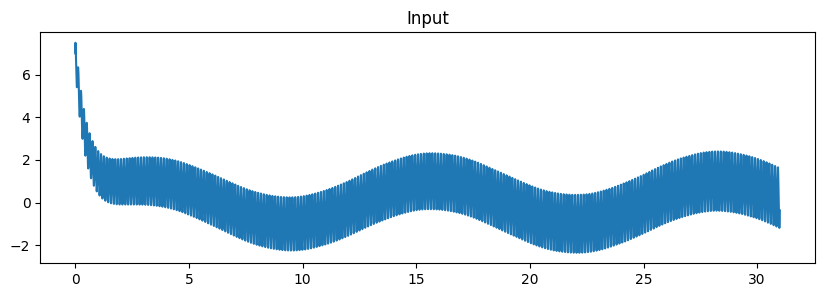

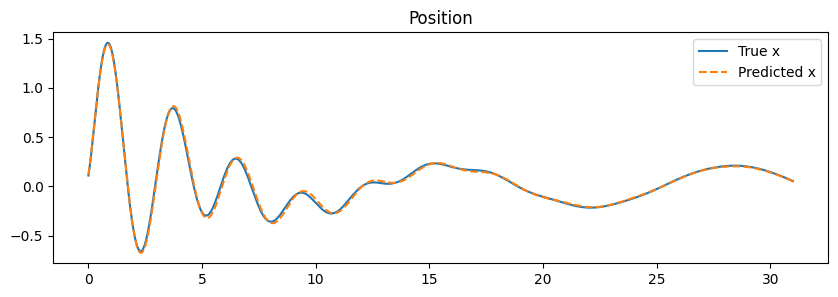

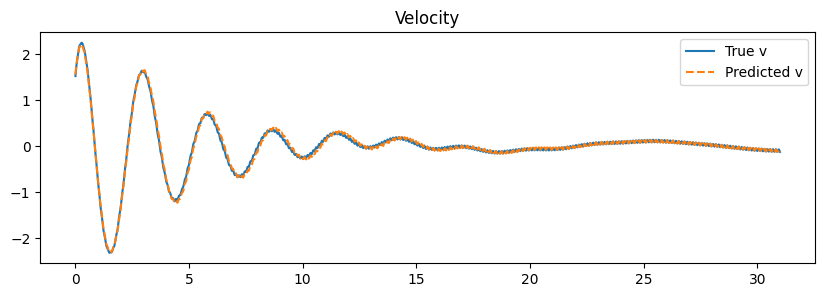

In [19]:
# Rollout prediction - for arbitrary input

def control_test(t):
    return 1*np.sin(0.5*t) + (t**0.1)*np.cos(50*t) + 7*np.exp(-2*t)

def z_dynamics(z_inital, A, B, t_eval, ctrl_fun):
    z = z_inital.reshape(2,1)
    z_hist = []
    for t in t_eval:
        u = ctrl_fun(t).reshape(1,1)
        z_next = A @ z + B @ u
        z_hist.append(z_next)
        z = z_next 
    
    z_hist = np.array(z_hist)
    return z_hist

# Simulation settings
# N      = 50
dt      = t_eval_train[1] - t_eval_train[0] 
T       = 31
t_eval_test = np.arange(0, T, dt)

# Initial condition
x0 = np.round(np.random.uniform(low=0,high=2, size=2), 2) # [1.0, 0.0]

print(f"Initial conidtion: {x0}")
print(f"t_start: {t_eval_test[0]} s | t_end: {t_eval_test[-1]} s | t_points: {t_eval_test.shape[0]} | dt: {dt} s | Sampling freq: {1/dt} Hz")



# Simulation of dynamics
sol_x = solve_ivp(dynamics, [0, T], x0, t_eval=t_eval_test, args=(control_test,Ac_true,Bc_true))
sol_z = z_dynamics(x0, Ad, Bd, t_eval_test, control_test).reshape(len(t_eval_test),2,).T

print(sol_x.y.shape, sol_z.shape)



# Plot
plt.figure(figsize=(10,3))
plt.plot(t_eval_test,control_test(t_eval_test))
plt.title("Input")

plt.figure(figsize=(10,3))
plt.plot(t_eval_test,sol_x.y[0], label="True x")
plt.plot(t_eval_test,sol_z[0], '--', label="Predicted x")
plt.legend()
plt.title("Position")

plt.figure(figsize=(10,3))
plt.plot(t_eval_test,sol_x.y[1], label="True v")
plt.plot(t_eval_test,sol_z[1], '--', label="Predicted v")
plt.legend()
plt.title("Velocity")

plt.show()

##### Changing to different time stepping

t_start: 0.0 s | t_end: 31.0 s | t_points: 500 | dt_new: 0.06212424849699399 s | Sampling freq: 16.096774193548388 Hz
Initial conidtion: [1.15 0.97]
(2, 500) (2, 500)


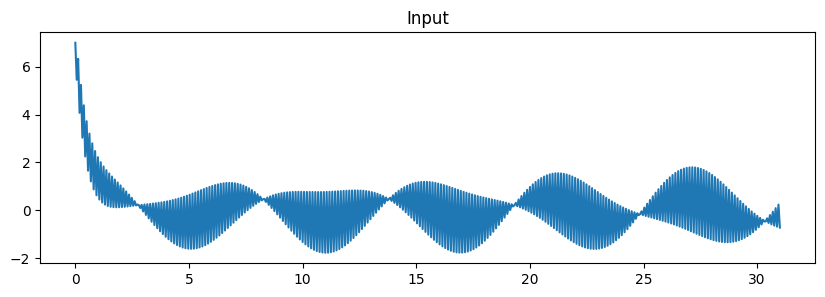

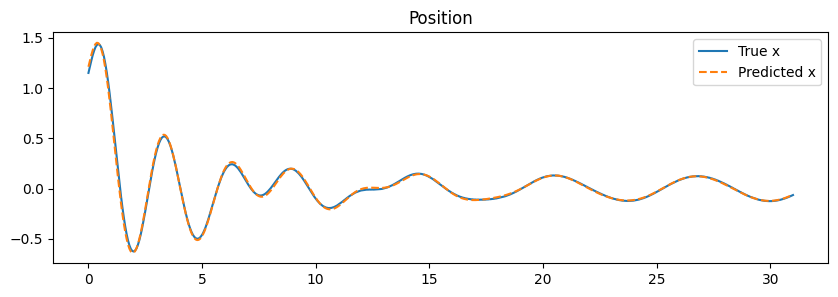

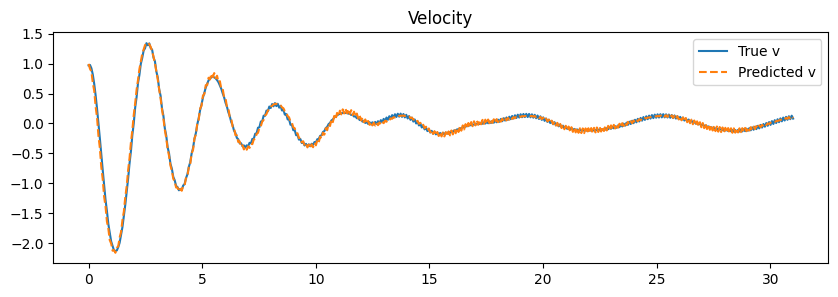

In [20]:
# Rollout prediction - for arbitrary input

# Simulation settings
N      = 500
T      = 31
t_eval_test = np.linspace(0, T, N)
dt_new      = t_eval_test[1] - t_eval_test[0]
print(f"t_start: {t_eval_test[0]} s | t_end: {t_eval_test[-1]} s | t_points: {t_eval_test.shape[0]} | dt_new: {dt_new} s | Sampling freq: {1/dt_new} Hz")

def control_test(t):
    return 0.5*np.sin(1*t) + t**0.1*np.cos(50*t) + 7*np.exp(-2*t)


def z_dynamics(z_inital, A, B, t_eval, ctrl_fun):
    z = z_inital.reshape(2,1)
    z_hist = []
    for k in range(len(t_eval)):
        u       = np.array([[ctrl_fun(t_eval[k])]])
        z_next  = A @ z + B @ u
        z_hist.append(z_next)
        z = z_next 
    
    z_hist = np.array(z_hist)
    return z_hist


# Initial condition
x0 = np.round(np.random.uniform(low=0,high=2, size=2), 2) # [1.0, 0.0]

print(f"Initial conidtion: {x0}")



from scipy.linalg import expm

n = Ac_est.shape[0]
m = Bc_est.shape[1]

M = np.block([
    [Ac_est, Bc_est],
    [np.zeros((m, n)), np.zeros((m, m))]
])

Md = expm(M * dt_new)

Aest_new = Md[:n, :n]
Best_new = Md[:n, n:]



# Simulation of dynamics
sol_x = solve_ivp(dynamics, [0, T], x0, t_eval=t_eval_test, args=(control_test,Ac_true,Bc_true))
sol_z = z_dynamics(x0, Aest_new, Best_new, t_eval_test, control_test).reshape(len(t_eval_test),2,).T

print(sol_x.y.shape, sol_z.shape)



# Plot
plt.figure(figsize=(10,3))
plt.plot(t_eval_test,control_test(t_eval_test))
plt.title("Input")

plt.figure(figsize=(10,3))
plt.plot(t_eval_test,sol_x.y[0], label="True x")
plt.plot(t_eval_test,sol_z[0], '--', label="Predicted x")
plt.legend()
plt.title("Position")

plt.figure(figsize=(10,3))
plt.plot(t_eval_test,sol_x.y[1], label="True v")
plt.plot(t_eval_test,sol_z[1], '--', label="Predicted v")
plt.legend()
plt.title("Velocity")

plt.show()